# Static-model dRSA hierarchy

Compare registered static vision models against the same dynamic ConvRNN target.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


@dataclass
class Cfg:
    env: str = os.getenv('MY_ENV', 'tiziano_mac_mini')
    model_names: tuple = ('vit_l_16', 'dino_v3_l', 'ijepa_vith14_1k')
    result_pattern: str = 'static_dRSA_cosine_cnt-cosine_cnt_*target_vs_*_spearman.npz'
    timestep_ms: float = 10.0
    centroid_weight_floor: float = 0.0
    heatmap_cmap: str = 'viridis'
    line_cmap: str = 'turbo'
    figure_dpi: int = 180


cfg = Cfg()
cfg

Cfg(env='tiziano_mac_mini', model_names=('vit_l_16', 'dino_v3_l', 'ijepa_vith14_1k'), result_pattern='static_dRSA_cosine_cnt-cosine_cnt_*target_vs_*_spearman.npz', timestep_ms=10.0, centroid_weight_floor=0.0, heatmap_cmap='viridis', line_cmap='turbo', figure_dpi=180)

In [2]:
search_paths = [Path.cwd().resolve()] + list(Path.cwd().resolve().parents)
PROJECT_ROOT = next(
    path for path in search_paths if (path / 'config.yaml').exists()
)
sys.path.append(str(PROJECT_ROOT / 'python_scripts' / 'src'))

from IT_recap.convrnn_analysis import load_paths
from IT_recap.static_drsa import (
    find_static_drsa_results,
    layer_depth_labels,
    save_centroid_table,
    save_static_drsa_figure,
    temporal_centroids,
)

paths = load_paths(PROJECT_ROOT, cfg.env)
data_path = Path(paths.get('it_recap_data_path', paths['data_path']))
RESULTS_DIR = data_path / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
results_by_model = find_static_drsa_results(
    RESULTS_DIR,
    cfg.result_pattern,
    timestep_ms=cfg.timestep_ms,
    model_names=cfg.model_names,
)

for model_name, result in results_by_model.items():
    print(model_name, result['path'].name, result['drsa'].shape)
# end for model_name, result in results_by_model.items():

vit_l_16 static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman.npz (16, 24)
dino_v3_l static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_dino_v3_l_spearman.npz (16, 24)
ijepa_vith14_1k static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_ijepa_vith14_1k_spearman.npz (16, 32)


PosixPath('/Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_models_heatmaps.png')

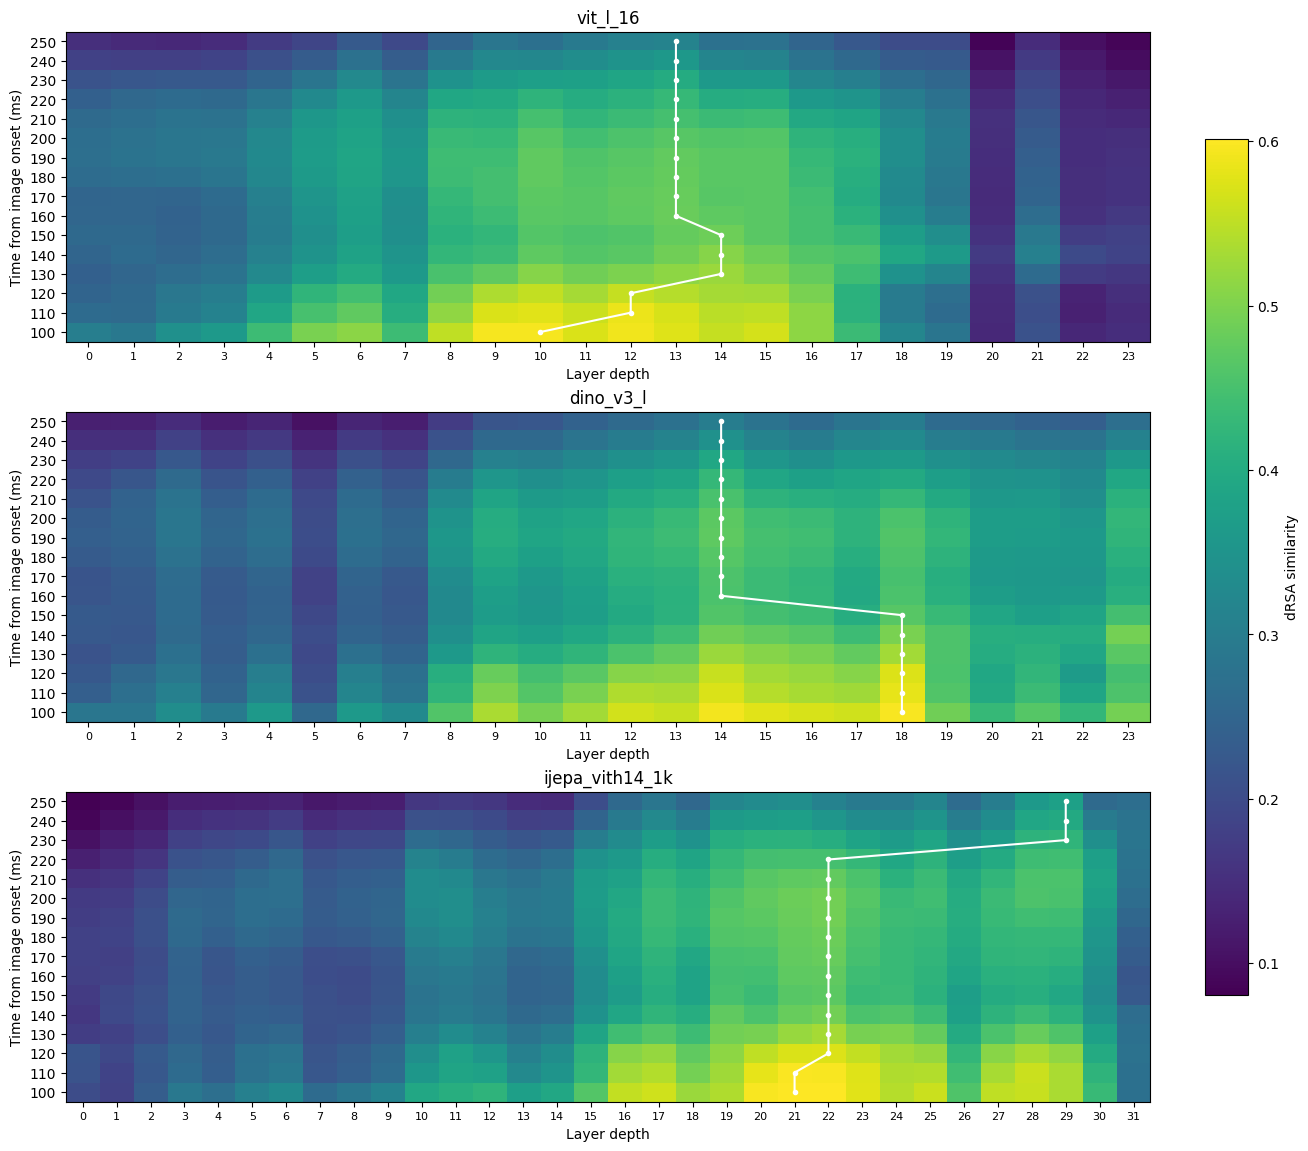

In [3]:
all_values = np.concatenate([result['drsa'].ravel() for result in results_by_model.values()])
vmin, vmax = np.nanmin(all_values), np.nanmax(all_values)
fig, axes = plt.subplots(
    len(results_by_model),
    1,
    figsize=(13, 3.8 * len(results_by_model)),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, (model_name, result) in zip(axes, results_by_model.items()):
    drsa = result['drsa']
    time_ms = result['time_ms']
    layers = result['layers']
    image = ax.imshow(
        drsa,
        aspect='auto',
        origin='lower',
        cmap=cfg.heatmap_cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.plot(
        result['best_layer_idx'],
        np.arange(len(time_ms)),
        color='white',
        marker='o',
        lw=1.5,
        ms=3,
    )
    ax.set_title(model_name)
    ax.set_xlabel('Layer depth')
    ax.set_ylabel('Time from image onset (ms)')
    ax.set_xticks(np.arange(len(layers)))
    ax.set_xticklabels(layer_depth_labels(layers), fontsize=8)
    ax.set_yticks(np.arange(len(time_ms)))
    ax.set_yticklabels(time_ms.astype(int))
# end for ax, (model_name, result) in zip(...):

fig.colorbar(image, ax=axes, label='dRSA similarity', shrink=0.8)
HEATMAP_PATH = save_static_drsa_figure(
    fig,
    FIGURES_DIR,
    Path('static_dRSA_models.npz'),
    'heatmaps',
    dpi=cfg.figure_dpi,
)
HEATMAP_PATH

PosixPath('/Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_models_layer_timecourses.png')

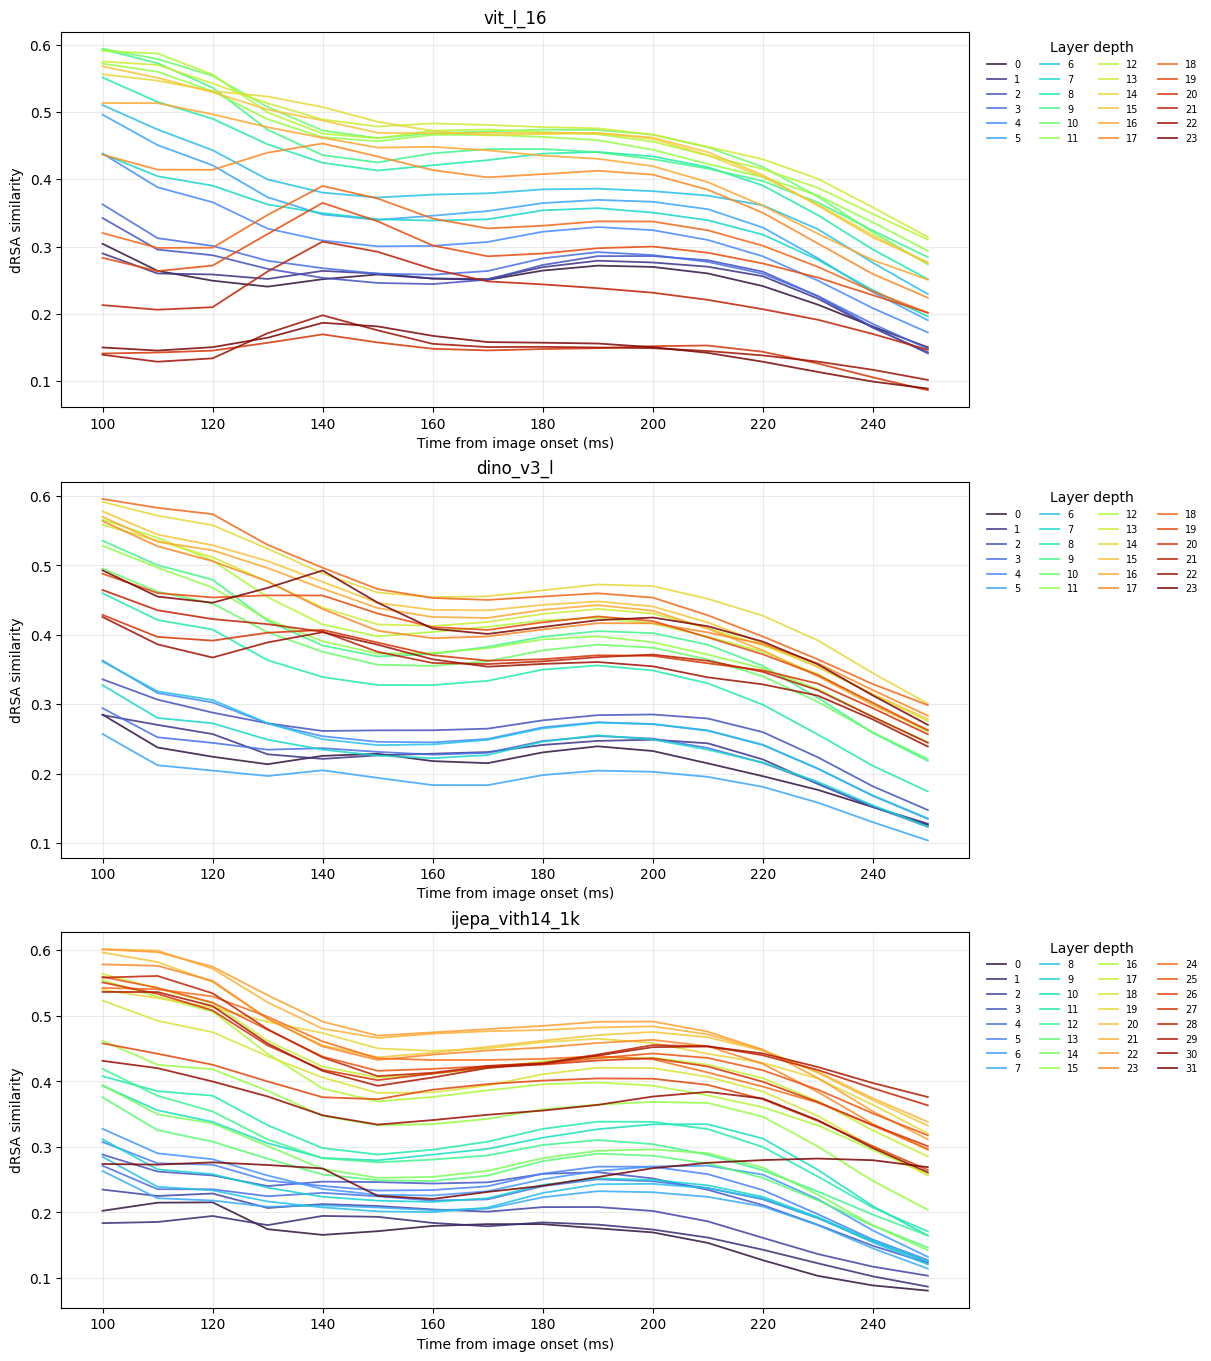

In [4]:
fig, axes = plt.subplots(
    len(results_by_model),
    1,
    figsize=(12, 4.5 * len(results_by_model)),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, (model_name, result) in zip(axes, results_by_model.items()):
    drsa = result['drsa']
    time_ms = result['time_ms']
    colors = plt.get_cmap(cfg.line_cmap)(np.linspace(0, 1, drsa.shape[1]))
    for layer_idx, color in enumerate(colors):
        ax.plot(
            time_ms,
            drsa[:, layer_idx],
            color=color,
            lw=1.3,
            alpha=0.85,
            label=str(layer_idx),
        )
    # end for layer_idx, color in enumerate(colors):
    ax.set_title(model_name)
    ax.set_xlabel('Time from image onset (ms)')
    ax.set_ylabel('dRSA similarity')
    ax.grid(True, alpha=0.25)
    ax.legend(
        title='Layer depth',
        ncol=4,
        fontsize=7,
        frameon=False,
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
    )
# end for ax, (model_name, result) in zip(...):

TIMECOURSE_PATH = save_static_drsa_figure(
    fig,
    FIGURES_DIR,
    Path('static_dRSA_models.npz'),
    'layer_timecourses',
    dpi=cfg.figure_dpi,
)
TIMECOURSE_PATH

PosixPath('/Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_models_best_normalized_layer.png')

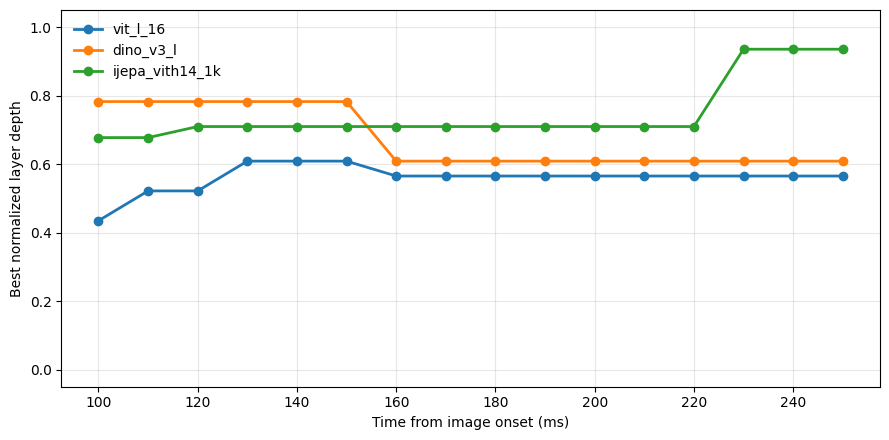

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for model_name, result in results_by_model.items():
    n_layers = len(result['layers'])
    normalized_depth = result['best_layer_idx'] / max(1, n_layers - 1)
    ax.plot(
        result['time_ms'],
        normalized_depth,
        marker='o',
        lw=2,
        label=model_name,
    )
# end for model_name, result in results_by_model.items():

ax.set_xlabel('Time from image onset (ms)')
ax.set_ylabel('Best normalized layer depth')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
BEST_LAYER_PATH = save_static_drsa_figure(
    fig,
    FIGURES_DIR,
    Path('static_dRSA_models.npz'),
    'best_normalized_layer',
    dpi=cfg.figure_dpi,
)
BEST_LAYER_PATH

PosixPath('/Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_models_centroids.png')

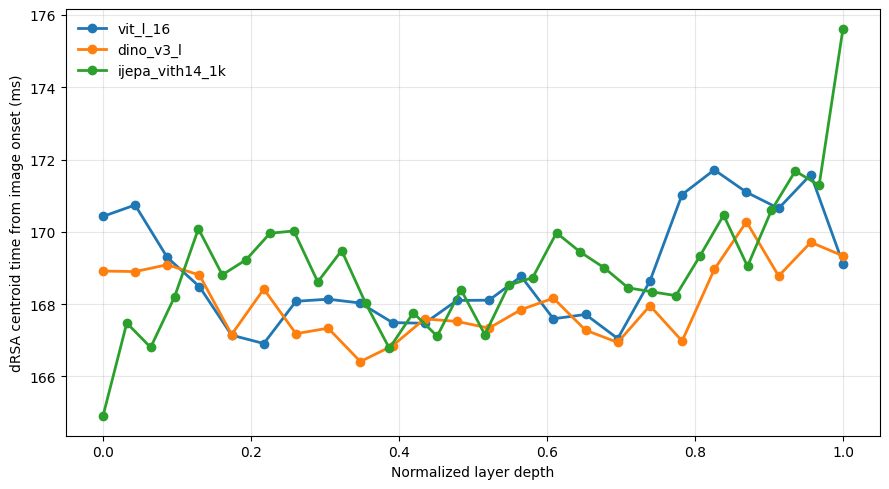

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
centroids_by_model = {}

for model_name, result in results_by_model.items():
    centroids_ms = temporal_centroids(
        result['time_ms'],
        result['drsa'],
        weight_floor=cfg.centroid_weight_floor,
    )
    centroids_by_model[model_name] = centroids_ms
    normalized_depth = np.linspace(0, 1, len(centroids_ms))
    ax.plot(
        normalized_depth,
        centroids_ms,
        marker='o',
        lw=2,
        label=model_name,
    )
    table_path = (
        FIGURES_DIR / f"{result['path'].stem}_layer_centroids.csv"
    )
    save_centroid_table(table_path, result['layers'], centroids_ms)
# end for model_name, result in results_by_model.items():

ax.set_xlabel('Normalized layer depth')
ax.set_ylabel('dRSA centroid time from image onset (ms)')
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
CENTROID_PATH = save_static_drsa_figure(
    fig,
    FIGURES_DIR,
    Path('static_dRSA_models.npz'),
    'centroids',
    dpi=cfg.figure_dpi,
)
CENTROID_PATH